In [14]:
# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Load Data
df_songs = pd.read_csv("C:/fiifi/Shatta_Analytics_Project/Python_files/python_data_analysis/songs_fact.csv", index_col=0)
df_metrics = pd.read_csv("C:/fiifi/Shatta_Analytics_Project/Python_files/python_data_analysis/platform_metrics_dim.csv", index_col=0)

In [15]:
# Filter for youtube only
df_youtube = df_metrics[df_metrics["platform_name"] == "YouTube"].copy()

# Merge df_youtube & df_songs
df_merged = df_songs.merge(right=df_youtube, how="inner", on="song_id")

# Drop release_date_original and release_date_original.1
df_merged = df_merged.drop(columns=["release_date_original", "release_date_original.1"])

# Convert release_date  to datetime
df_merged["release_date"] = pd.to_datetime(df_merged["release_date"], dayfirst=False, errors="coerce")

In [21]:
# Get month from release_date
df_merged["month_no"] = pd.to_datetime(df_merged["release_date"]).dt.month

# # Get full day name
df_merged["month_name"] = pd.to_datetime(df_merged["release_date"]).dt.month_name()

# Calculate song age
reference_date = datetime.now()
df_merged["age_days"] = (reference_date - df_merged["release_date"]).dt.days

# Filter for songs 90 days or more
df_mature = df_merged[df_merged["age_days"] >=90].copy()

# sort by month_no
df_mature = df_mature.sort_values(by="month_no", ascending=True)

# Groupby month no
df_monthly_group = df_mature.groupby(by="month_name")["views"].agg(["mean", "median"]).round(1).sort_values(by="mean", ascending=False)

In [22]:
df_monthly_group

,mean,median
month_name,,
April,1100858.9,108630.5
March,952346.5,90562.0
December,611026.6,66690.0
July,456885.5,97519.5
May,452745.8,105493.0
February,421054.7,91238.0
August,328076.5,81335.5
January,244212.8,117070.0
June,234128.6,95820.0


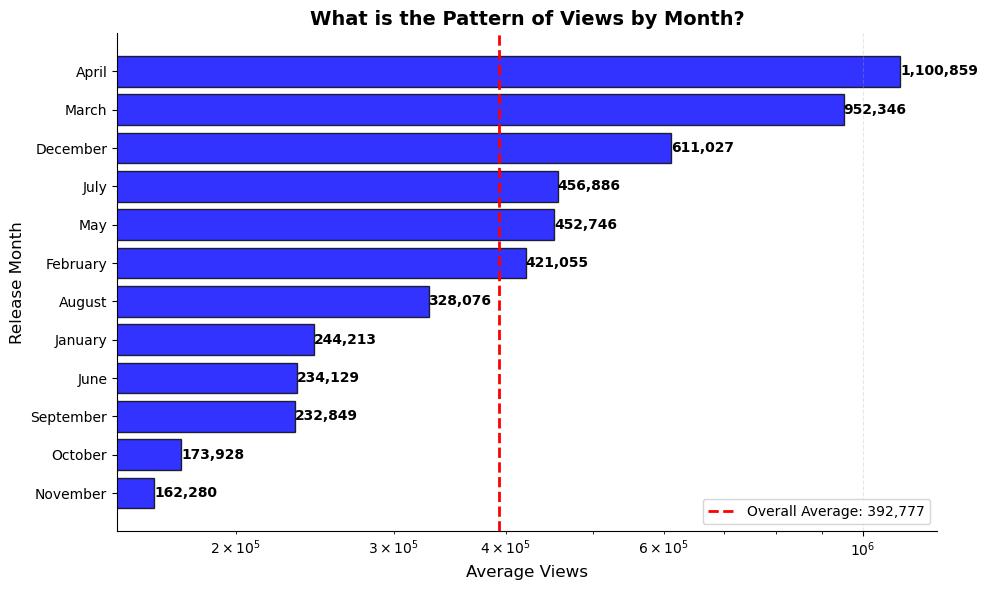

In [28]:
# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))

# Plot horizontal bars
bars = ax.barh(df_monthly_group.index, df_monthly_group['mean'], color='blue', edgecolor='black', alpha=0.8)

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars, df_monthly_group['mean'])):
    ax.text(value, bar.get_y() + bar.get_height()/2, f'{value:,.0f}', 
            va='center', ha='left', fontsize=10, fontweight='bold')

# Customize the chart
ax.set_xlabel('Average Views', fontsize=12)
ax.set_ylabel('Release Month', fontsize=12)
ax.set_title('What is the Pattern of Views by Month?', fontsize=14, fontweight='bold')
ax.invert_yaxis()  # Best day at top
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.xscale('log')

# Despine - remove right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Add a vertical line for overall average
overall_avg = df_merged['views'].mean()
ax.axvline(x=overall_avg, color='red', linestyle='--', linewidth=2, 
           label=f'Overall Average: {overall_avg:,.0f}')

# Add legend
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

Insights:
- April is the strongest release month by a wide margin – With over 1.1 million average views, April outperforms the second-best month (March at 952,346) by nearly 150,000 views
- March and December form the second tier – Both months generate over 600,000 average views, making them solid alternatives to April
- November is the weakest month – At only 162,280 average views, November releases underperform by nearly 7x compared to April

Recommendations
- Schedule flagship releases in April – The data clearly shows April as the peak performing month; plan album launches and major singles for this window
- Avoid November releases – November shows the lowest average views; use this month for planning, recording, or building anticipation for December/January releases
- Use March and December for secondary releases – If April is unavailable, March and December are your next best options based on historical performance